# Setup

In [1]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dunetrg.data.workspace as workspace
import dunetrg.analysis.snn as snn
import mplhep as hep

from rich import print


In [3]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data

In [4]:
import dunetrg.data.datacatalogue as dctl

dataset_name = 'radbkg'
datasets = dctl.load('vd/1x8x14/3sig', dataset_name)
rad_ws=datasets[dataset_name]


Loading radbkg

Dataset 'radbkg': 10 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [
        [28, 'Rn222ChainFromPo218GenInUpperMesh1x8x14'],
        [27, 'Rn220ChainFromPb212GenInUpperMesh1x8x14'],
        [26, 'Kr85GenInLAr'],
        [25, 'Rn222ChainFromBi210GenInUpperMesh1x8x14'],
        [24, 'U238ChainGenInAnode'],
        [23, 'K40GenInCathode'],
        [22, 'K42From42ArGenInUpperMesh1x8x14'],
        [21, 'Th232ChainGenInCathode'],
        [20, 'CavernNGammasAtLAr1x8x14'],
        [19, 'Rn222ChainRn222GenInLAr'],
        [18, 'U238ChainGenInCathode'],
        [17, 'K40GenInAnode'],
        [16, 'Rn220ChainPb212GenInLAr'],
        [15, 'foamGammasAtLAr1x8x14'],
        [14, 'Rn222ChainFromPb214GenInUpperMesh1x8x14'],
        [13, 'K42From42ArGenInLAr'],
        [12, 'Rn222ChainGenInPDS'],
        [11, 'Ar42GenInLAr'],
        [10, 'CavernwallGammasAtLAr1x8x14'],
        [9, 'Rn222ChainPb210GenInLAr'],
        [8, 'Ar39GenInLAr'],
        [7, 'Rn222ChainPb214GenInLAr'],
        [6, 'Rn222ChainFromPb210GenInUpperMesh1x8x14'],
        [5, 'Rn222ChainPo218GenInLAr'],
        [4, 'CavernwallNeutronsAtLAr1x8x14'],
        [3, 'Rn222ChainFromBi214GenInUpperMesh1x8x14'],
        [2, 'CryostatNGammasAtLAr1x8x14'],
        [1, 'Th232ChainGenInAnode'],
        [0, 'Rn222ChainBi214GenInLAr']
    ],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 27,
            'threshold_tpg_plane1': 27,
            'threshold_tpg_plane2': 27,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    },
    'detector_properties': {'readout_window': 8500}
}

In [5]:
from dunetrg.analysis.viz.tps import TrgPrimitivesPlotter

tpp = TrgPrimitivesPlotter(rad_ws)

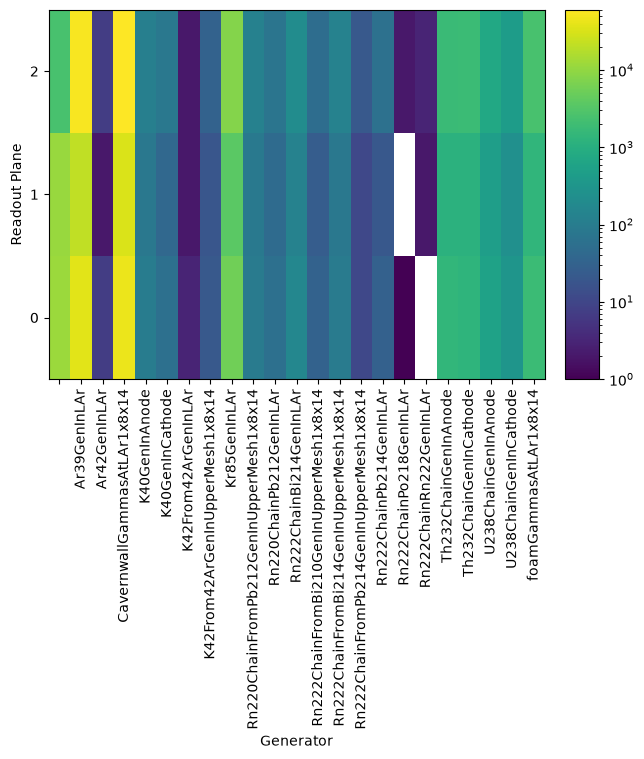

In [6]:

from matplotlib.colors import LogNorm

fig, ax = plt.subplots()
h = tpp.make_generator_counts_hist('adc_peak > 45')
norm = LogNorm(vmin=1, vmax=h.values().max())

hep.hist2dplot(h, ax=ax,  norm=norm)
ax.tick_params(axis='x', rotation=90)


In [7]:
h[sum, :]

Hist(IntCategory([0, 1, 2], name='readout_plane_id', label='Readout Plane'), storage=Double()) # Sum: 311623.0

In [11]:
print(tpp.make_generator_activity_table( "adc_peak >45"))

                                         Rates per generator (1x8x14)                                          
┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃    ┃ generator                               ┃ rate          ┃ rate_rop0     ┃ rate_rop1    ┃ rate_rop2     ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 3  │ CavernwallGammasAtLAr1x8x14             │ 3226352.94 Hz │ 1035529.41 Hz │ 761764.71 Hz │ 1429058.82 Hz │
│ 1  │ Ar39GenInLAr                            │ 2669741.18 Hz │ 868494.12 Hz  │ 490305.88 Hz │ 1310941.18 Hz │
│ 0  │ DetSimElecNoise                         │ 589882.35 Hz  │ 269576.47 Hz  │ 263435.29 Hz │ 56870.59 Hz   │
│ 8  │ Kr85GenInLAr                            │ 398752.94 Hz  │ 130917.65 Hz  │ 85435.29 Hz  │ 182400.00 Hz  │
│ 22 │ foamGammasAtLAr1x8x14                   │ 132517.65 Hz  │ 42752.94 Hz   │ 32164.71 Hz  │ 57600.00 Hz   │
│ 18 │ Th232ChainGenInAnode                    │ 101082.35 Hz  │ 32823.53 Hz   │ 26541.18 Hz  │ 41717.65 Hz   │
│ 19 │ Th232ChainGenInCathode                  │ 99788.24 Hz   │ 30070.59 Hz   │ 26847.06 Hz  │ 42870.59 Hz   │
│ 20 │ U238ChainGenInAnode                     │ 41623.53 Hz   │ 13694.12 Hz   │ 10847.06 Hz  │ 17082.35 Hz   │
│ 21 │ U238ChainGenInCathode                   │ 22988.24 Hz   │ 7223.53 Hz    │ 5670.59 Hz   │ 10094.12 Hz   │
│ 11 │ Rn222ChainBi214GenInLAr                 │ 11788.24 Hz   │ 3858.82 Hz    │ 3152.94 Hz   │ 4776.47 Hz    │
│ 13 │ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 7223.53 Hz    │ 2235.29 Hz    │ 1905.88 Hz   │ 3082.35 Hz    │
│ 9  │ Rn220ChainFromPb212GenInUpperMesh1x8x14 │ 7035.29 Hz    │ 2211.76 Hz    │ 2000.00 Hz   │ 2823.53 Hz    │
│ 4  │ K40GenInAnode                           │ 6870.59 Hz    │ 2282.35 Hz    │ 1952.94 Hz   │ 2635.29 Hz    │
│ 5  │ K40GenInCathode                         │ 4188.24 Hz    │ 1317.65 Hz    │ 917.65 Hz    │ 1952.94 Hz    │
│ 10 │ Rn220ChainPb212GenInLAr                 │ 4094.12 Hz    │ 1317.65 Hz    │ 1082.35 Hz   │ 1694.12 Hz    │
│ 15 │ Rn222ChainPb214GenInLAr                 │ 2541.18 Hz    │ 682.35 Hz     │ 470.59 Hz    │ 1388.24 Hz    │
│ 12 │ Rn222ChainFromBi210GenInUpperMesh1x8x14 │ 2447.06 Hz    │ 705.88 Hz     │ 588.24 Hz    │ 1152.94 Hz    │
│ 7  │ K42From42ArGenInUpperMesh1x8x14         │ 1647.06 Hz    │ 494.12 Hz     │ 447.06 Hz    │ 705.88 Hz     │
│ 14 │ Rn222ChainFromPb214GenInUpperMesh1x8x14 │ 1011.76 Hz    │ 258.82 Hz     │ 258.82 Hz    │ 494.12 Hz     │
│ 2  │ Ar42GenInLAr                            │ 376.47 Hz     │ 164.71 Hz     │ 47.06 Hz     │ 164.71 Hz     │
│ 6  │ K42From42ArGenInLAr                     │ 164.71 Hz     │ 70.59 Hz      │ 47.06 Hz     │ 47.06 Hz      │
│ 17 │ Rn222ChainRn222GenInLAr                 │ 117.65 Hz     │ 0.00 Hz       │ 47.06 Hz     │ 70.59 Hz      │
│ 16 │ Rn222ChainPo218GenInLAr                 │ 70.59 Hz      │ 23.53 Hz      │ 0.00 Hz      │ 47.06 Hz      │
└────┴─────────────────────────────────────────┴───────────────┴───────────────┴──────────────┴───────────────┘

# TP sample validation
## Distribution of point of origin in the detector

In [13]:
coll_tps = rad_ws.tps.query('readout_view == 2 & sample_start >100 & sample_start < 8100 & bt_is_signal == 1 ')
coll_tps.extra_info.update({'readout_window': 8000})


In [14]:
tps_by_gen = sorted([(n,df) for n,df in coll_tps.groupby('bt_generator_name')], reverse=True, key=lambda x: len(x[1]))


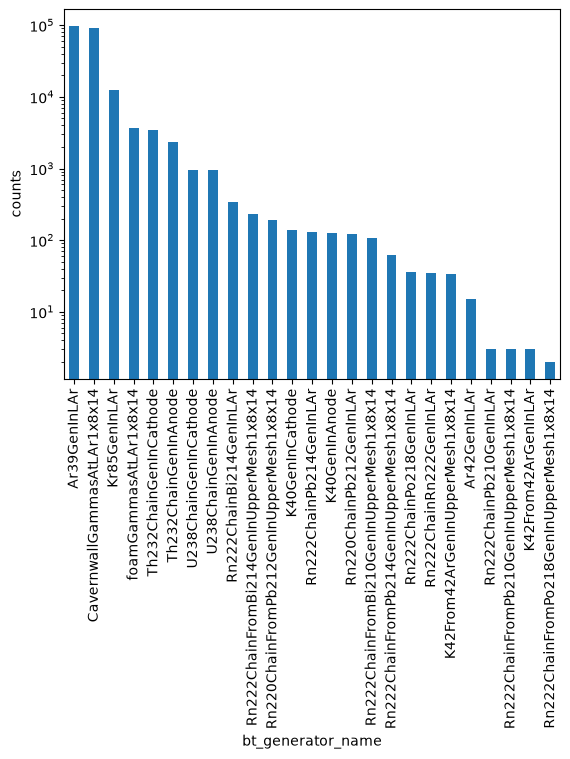

In [15]:
counts = coll_tps.bt_generator_name.value_counts()
ax = counts.plot.bar()
ax.set_ylabel('counts')
ax.set_yscale('log')

<StringArray>
[                           'Ar39GenInLAr',
             'CavernwallGammasAtLAr1x8x14',
                            'Kr85GenInLAr',
                   'foamGammasAtLAr1x8x14',
                  'Th232ChainGenInCathode',
                            'Ar42GenInLAr',
                     'U238ChainGenInAnode',
                    'Th232ChainGenInAnode',
                           'K40GenInAnode',
                   'U238ChainGenInCathode',
 'Rn222ChainFromBi210GenInUpperMesh1x8x14',
                         'K40GenInCathode',
                 'Rn222ChainPb214GenInLAr',
 'Rn222ChainFromBi214GenInUpperMesh1x8x14',
                 'Rn222ChainBi214GenInLAr',
                 'Rn220ChainPb212GenInLAr',
                 'Rn222ChainPo218GenInLAr',
 'Rn220ChainFromPb212GenInUpperMesh1x8x14',
 'Rn222ChainFromPb214GenInUpperMesh1x8x14',
                 'Rn222ChainRn222GenInLAr',
                 'Rn222ChainPb210GenInLAr',
         'K42From42ArGenInUpperMesh1x8x14',
 'Rn222ChainFromPo218GenInUpperMesh1x8x14',
 'Rn222ChainFromPb210GenInUpperMesh1x8x14',
                     'K42From42ArGenInLAr']
Length: 25, dtype: str

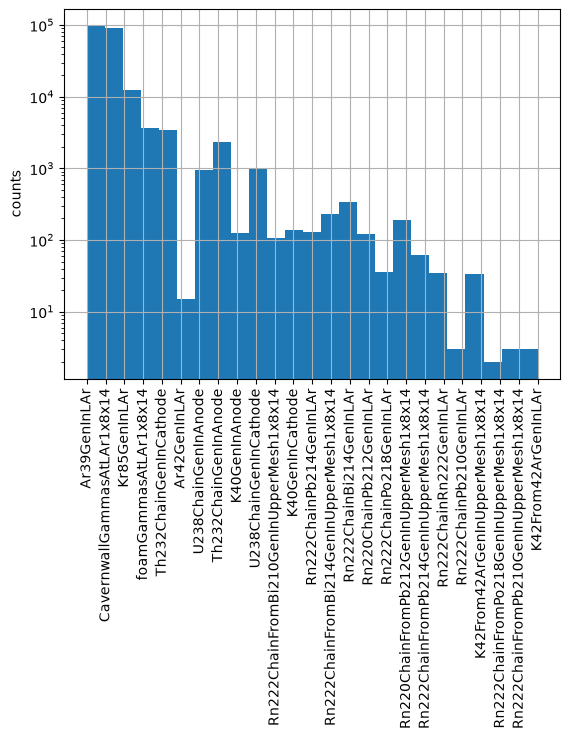

In [16]:
fig, ax = plt.subplots()

print(coll_tps.bt_generator_name.unique())
n_bins = coll_tps.bt_generator_name.nunique()
# coll_tps.bt_generator_name.hist(bins=n_bins)
coll_tps.bt_generator_name.hist(bins=n_bins)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation='vertical')
ax.set_ylabel('counts')
ax.set_yscale('log')

Text(0.5, 1.0, 'XY origin - Plane X [2]')

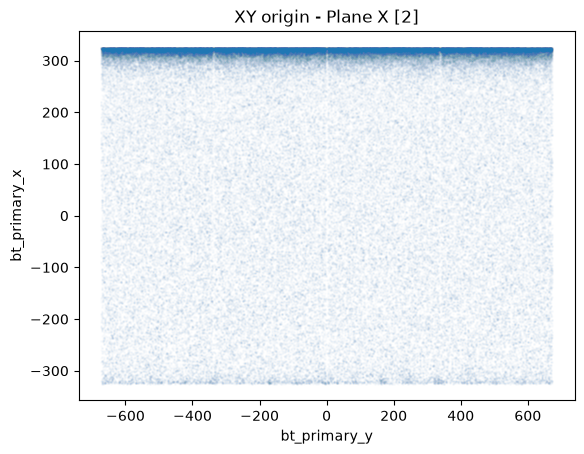

In [17]:
fig, axes = plt.subplots()

ax=axes
alpha=0.01
col=None
cmap=None
coll_tps.plot.scatter(x='bt_primary_y', y='bt_primary_x', alpha=alpha, c=col, cmap=cmap, s=1, ax=ax)
ax.set_title('XY origin - Plane X [2]')

In [18]:
top_by_gen = tps_by_gen[:10]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ Generator                               ┃ Counts ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ Ar39GenInLAr                            │ 97789  │
│ CavernwallGammasAtLAr1x8x14             │ 90401  │
│ Kr85GenInLAr                            │ 12364  │
│ foamGammasAtLAr1x8x14                   │ 3677   │
│ Th232ChainGenInCathode                  │ 3451   │
│ Th232ChainGenInAnode                    │ 2363   │
│ U238ChainGenInCathode                   │ 967    │
│ U238ChainGenInAnode                     │ 963    │
│ Rn222ChainBi214GenInLAr                 │ 340    │
│ Rn222ChainFromBi214GenInUpperMesh1x8x14 │ 230    │
└─────────────────────────────────────────┴────────┘

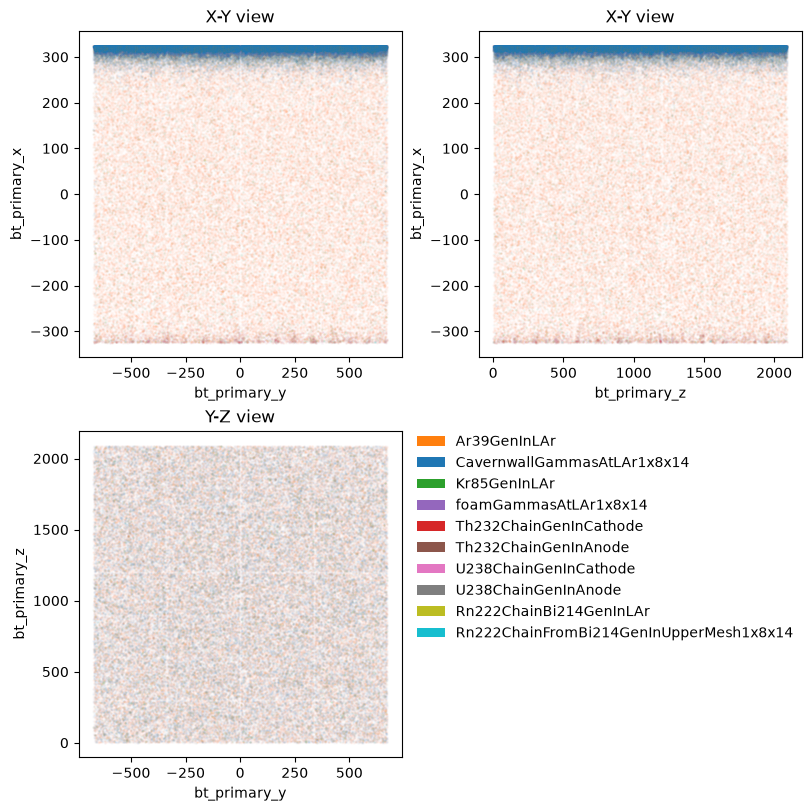

In [19]:
# cmap = plt.get_cmap('Paired')
cmap = plt.get_cmap('tab10')
alpha=0.01
colors = [1,0,2,4,3,5,6,7,8,9]

from rich.table import Table

t = Table('Generator', 'Counts')
for n, df in top_by_gen:
    t.add_row(n, str(len(df)))

print(t)

tps_plot = top_by_gen[::-1]
col_sorted = colors[:len(tps_plot)][::-1]

fig, axes = plt.subplots(2,2, figsize=(8,8), layout='constrained')

ax = axes[0][0]
for i, (n, df) in enumerate(tps_plot):
    df.plot.scatter(x='bt_primary_y', y='bt_primary_x', alpha=alpha, color=cmap(col_sorted[i]), s=1, ax=ax)
ax.set_title("X-Y view")

ax = axes[0][1]
for i, (n, df) in enumerate(tps_plot):
    df.plot.scatter(x='bt_primary_z', y='bt_primary_x', alpha=alpha, color=cmap(col_sorted[i]), s=1, ax=ax)
ax.set_title("X-Y view")


ax = axes[1][0]
for i, (n, df) in enumerate(tps_plot):
    df.plot.scatter(x='bt_primary_y', y='bt_primary_z', alpha=alpha, color=cmap(col_sorted[i]), s=1, ax=ax)
ax.set_title("Y-Z view")

ax = axes[1][1]
ax.set_axis_off()
# fig.legend(loc='outside right upper')

from matplotlib.patches import Patch

# --- Proxy fill-style legend entries ---
legend_handles = [
    Patch(facecolor='tab:blue', alpha=0.5, label='Signal'),
    Patch(facecolor='tab:orange', alpha=0.5, label='Background'),
]


legend_handles = [ Patch(facecolor=cmap(colors[i]), label=n)  for i, (n, df) in enumerate(top_by_gen) ]

# --- Shared legend, outside subplots ---
fig.legend(
    handles=legend_handles,
    loc='lower right',
    # ncol=2,
    frameon=False,
    bbox_to_anchor=(1., 0.19)
    # loc='outside right upper'
)


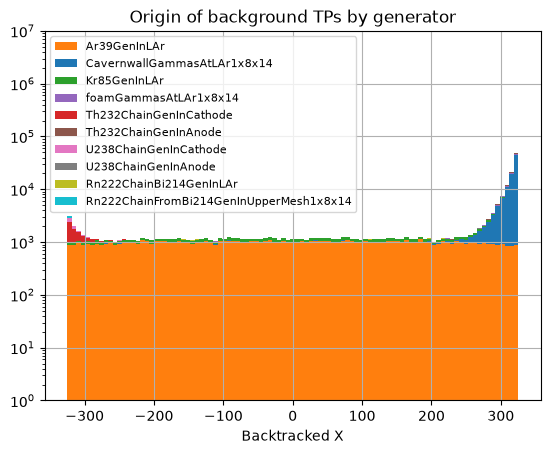

In [20]:

fig, ax = plt.subplots()

bins = np.linspace(-325, 325, 100)

colors = [1,0,2,4,3,5,6,7,8,9]


df = pd.concat([df for n, df in top_by_gen], axis=1)

ax.hist([df.bt_primary_x for n, df in top_by_gen], bins=bins, histtype='bar', stacked=True, color=[ cmap(colors[i]) for i, _ in enumerate(top_by_gen)], label=[n for n, df in top_by_gen])
ax.set_xlabel('Backtracked X')
ax.set_title('Origin of background TPs by generator')


# print(ax.get_ylim())
# ax.set_ylim(ymax=ax.get_ylim()[1]*10)
ax.set_ylim(1, ymax=10e6)
ax.set_yscale('log')
ax.grid()
ax.legend( prop={'size': 8})    

In [22]:
all_tps = snn.TPSignalNoiseSelector(rad_ws.tps)
alltp_ana = snn.TPSignalNoiseAnalyzer(all_tps)

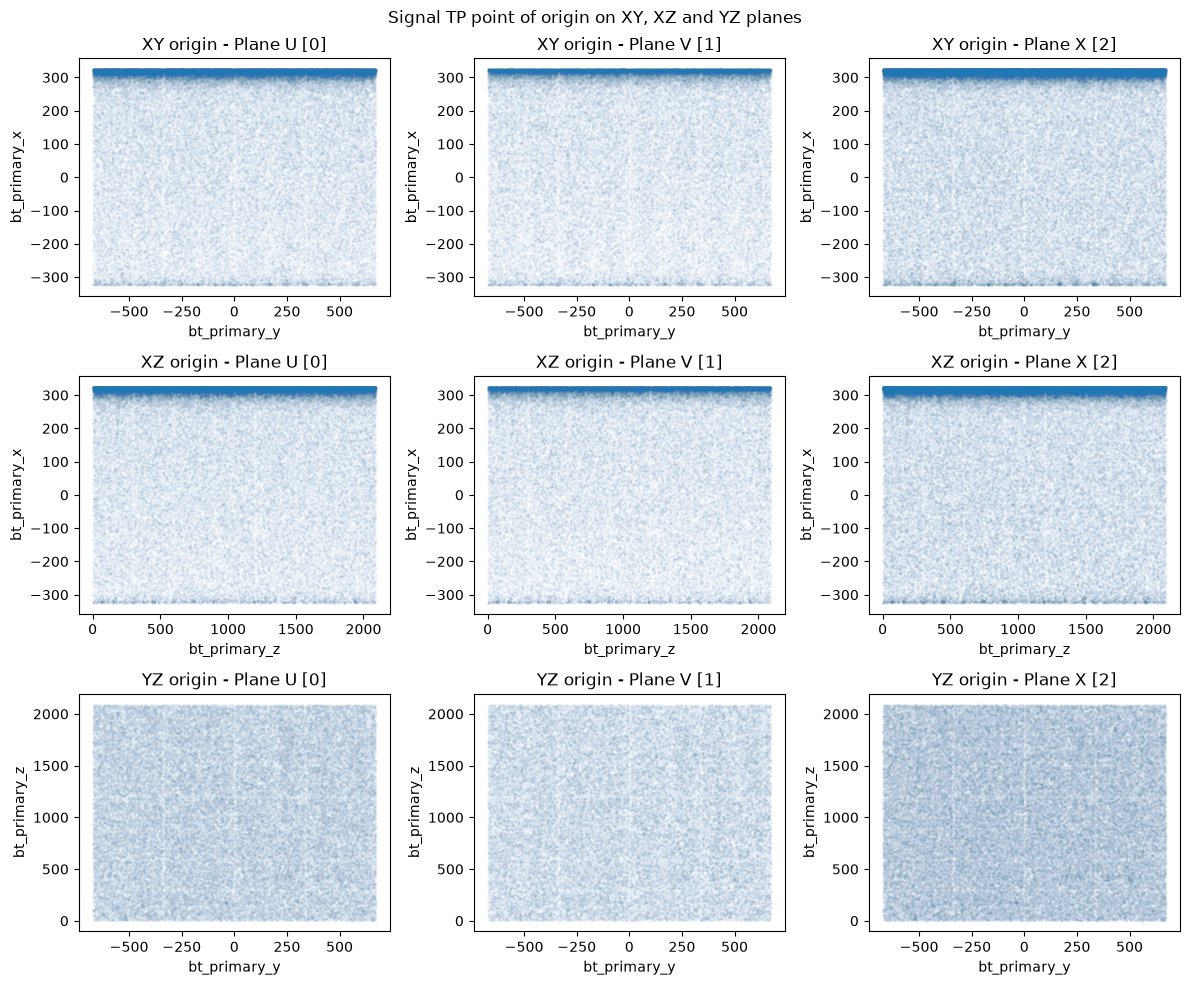

In [23]:
fig = alltp_ana.draw_tp_sig_origin_2d_dist()
fig.tight_layout()

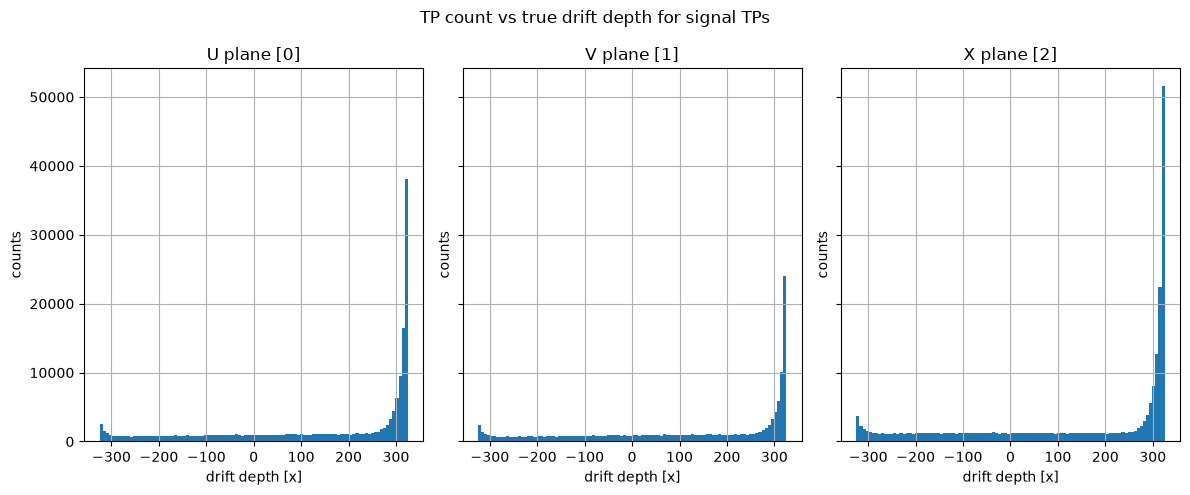

In [24]:
fig = alltp_ana.draw_tp_sig_drift_depth_dist()

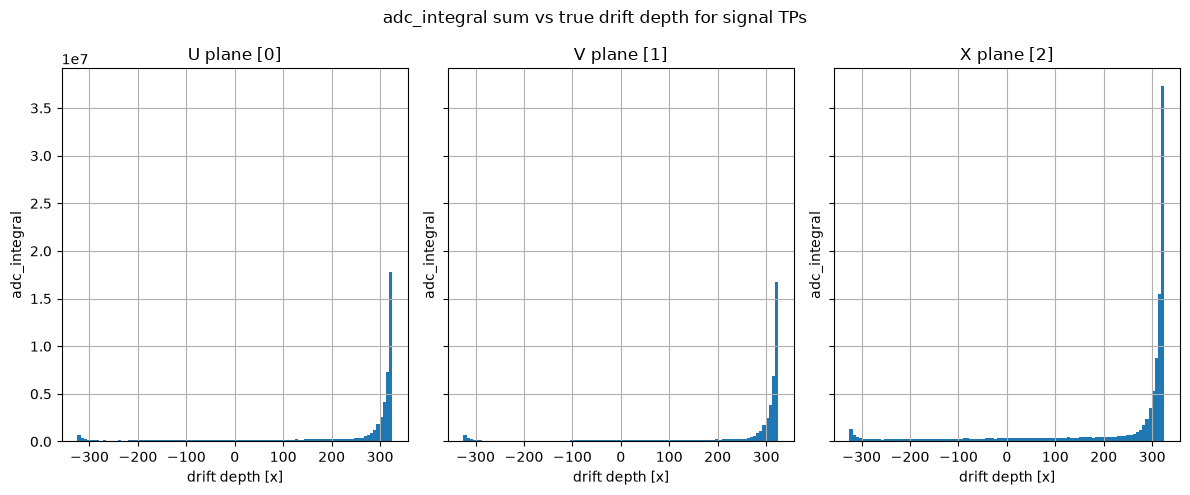

In [25]:
fig = alltp_ana.draw_tp_sig_drift_depth_dist(weight_by='adc_integral')

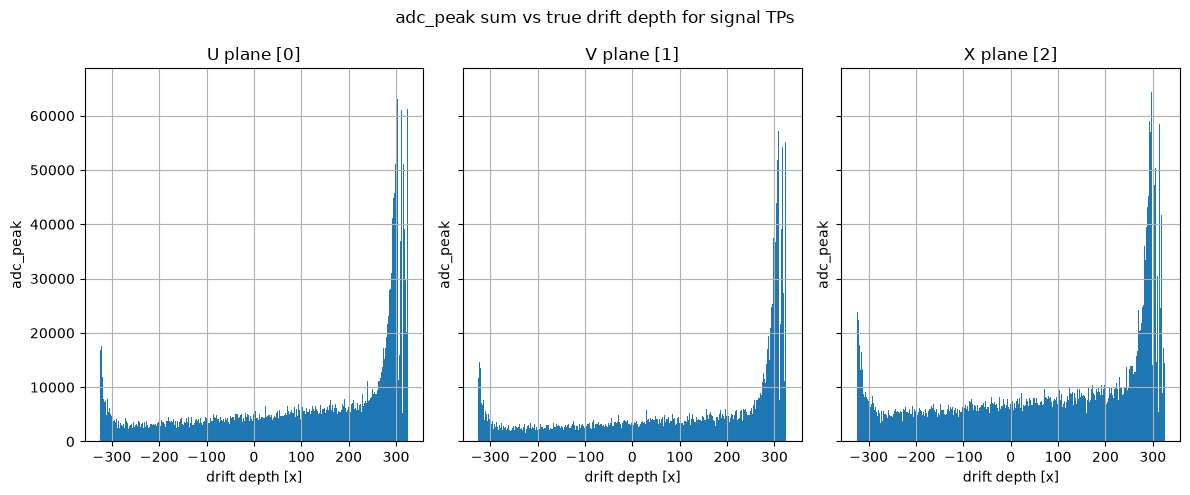

In [26]:
fig = alltp_ana.draw_tp_sig_drift_depth_dist(weight_by='adc_peak', bins=1000)

# Dataset validation: TP distributions

### TP distribution in channel and time - one event with increasing peak ADC cuts

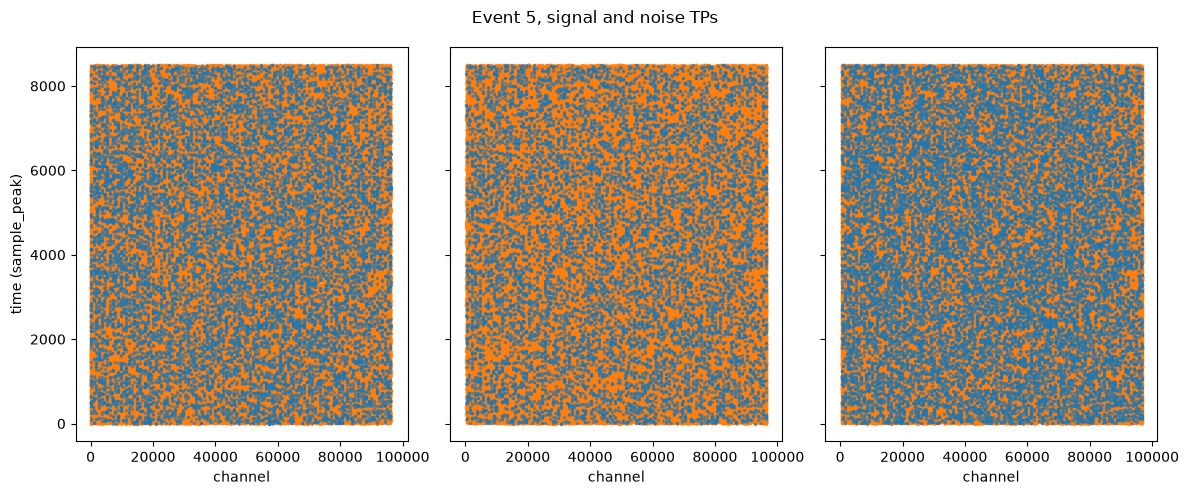

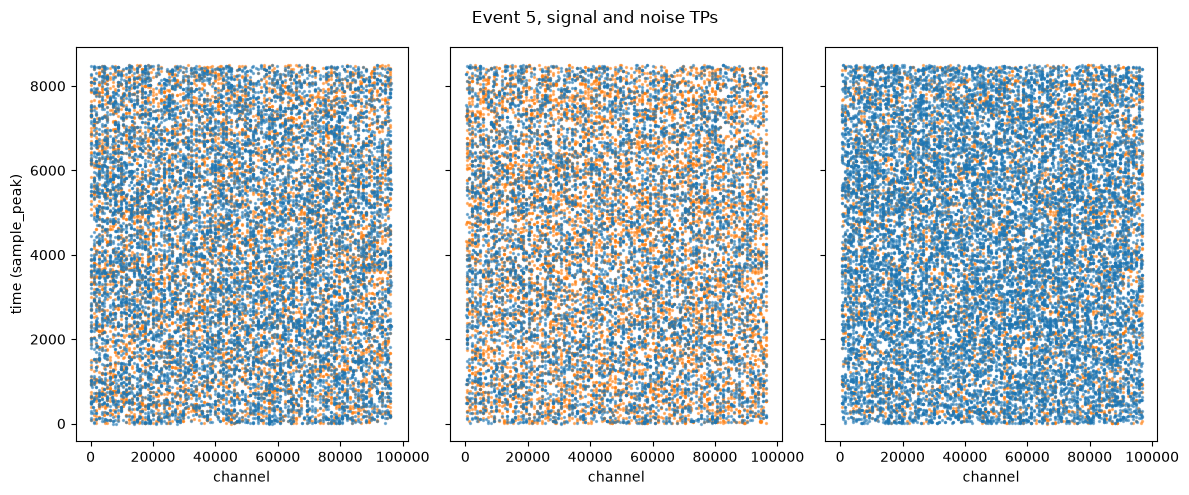

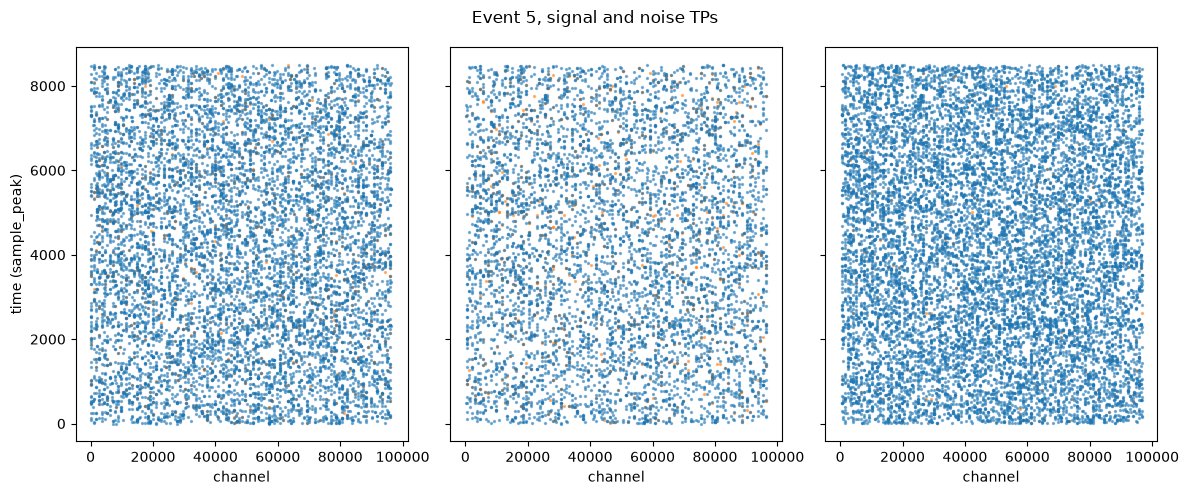

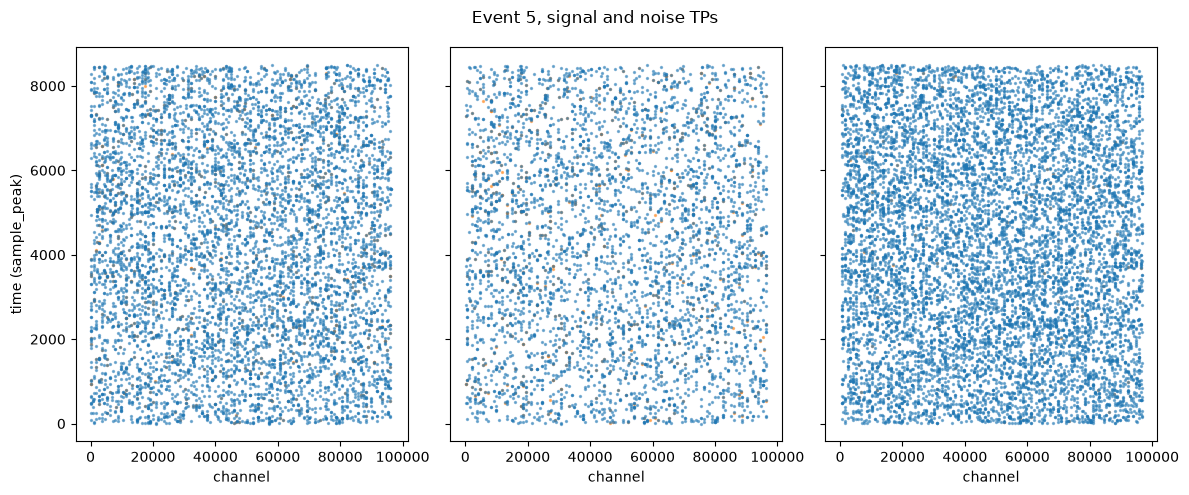

In [28]:
x = snn.TPSignalNoiseAnalyzer(all_tps.query('adc_peak > 26'))
fig = x.draw_tp_event(5)
x = snn.TPSignalNoiseAnalyzer(all_tps.query('adc_peak > 36'))
fig = x.draw_tp_event(5)
x = snn.TPSignalNoiseAnalyzer(all_tps.query('adc_peak > 46'))
fig = x.draw_tp_event(5)
x = snn.TPSignalNoiseAnalyzer(all_tps.query('adc_peak > 56'))
fig = x.draw_tp_event(5)


### TP distribution in channel and time - all events

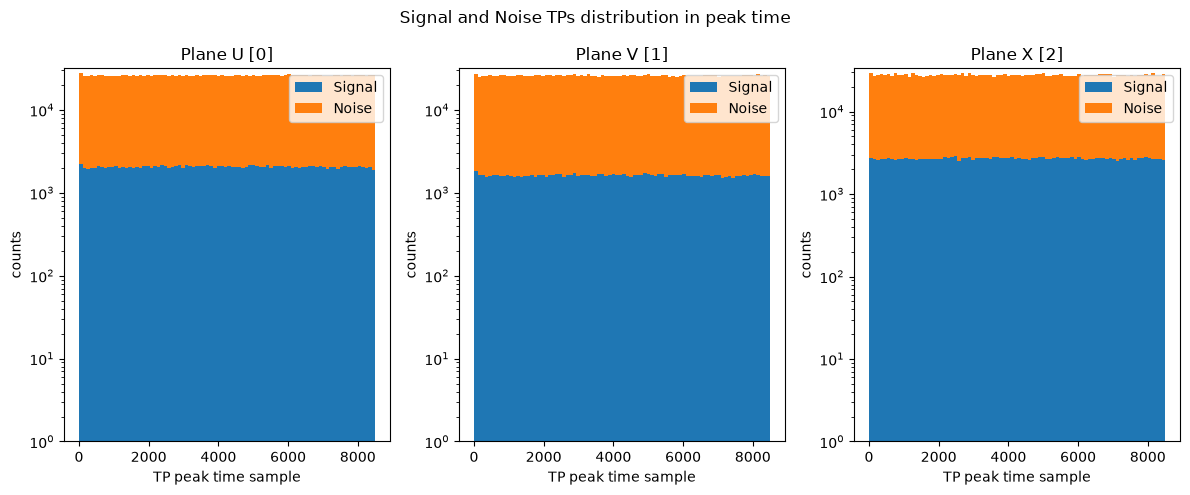

In [29]:
fig = alltp_ana.draw_tp_start_sample_dist()

# Cleaning: removing regions with non-even backtracking efficiency

In [32]:
tpw = snn.TPSignalNoiseSelector(rad_ws.tps[(rad_ws.tps.sample_start >100) & (rad_ws.tps.sample_start <8100)])
tp_ana = snn.TPSignalNoiseAnalyzer(tpw)

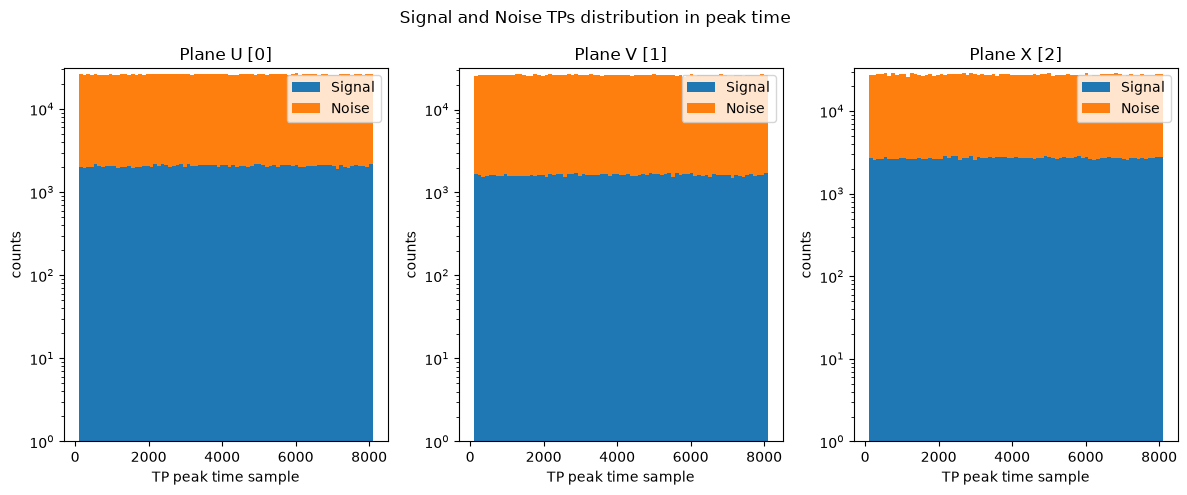

In [33]:
fig = tp_ana.draw_tp_start_sample_dist()


# adcpeak, time-over-threshold and SumADC distribution for Ar39 and noise

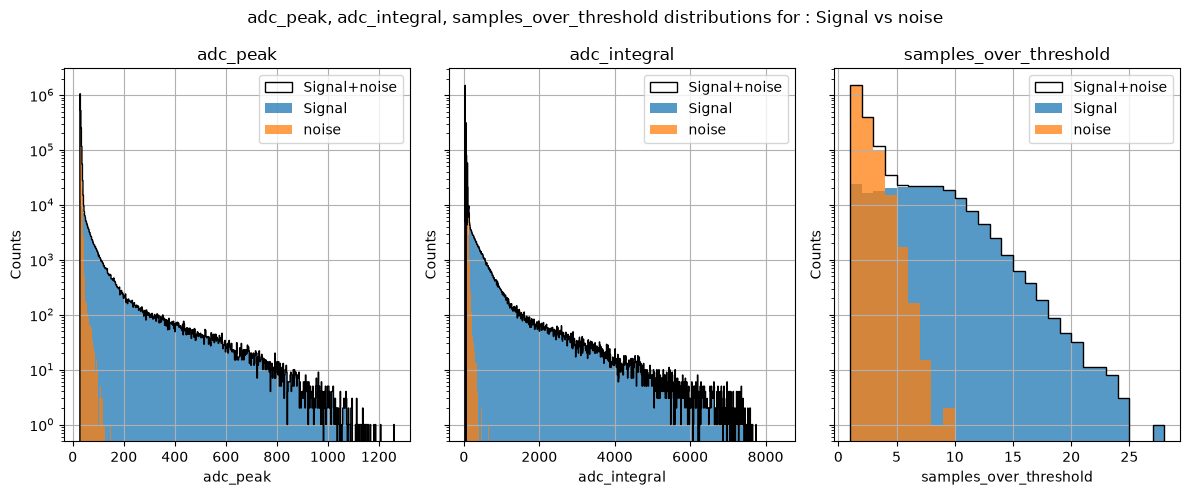

In [34]:
fig = tp_ana.draw_tp_signal_noise_dist()
fig.tight_layout()

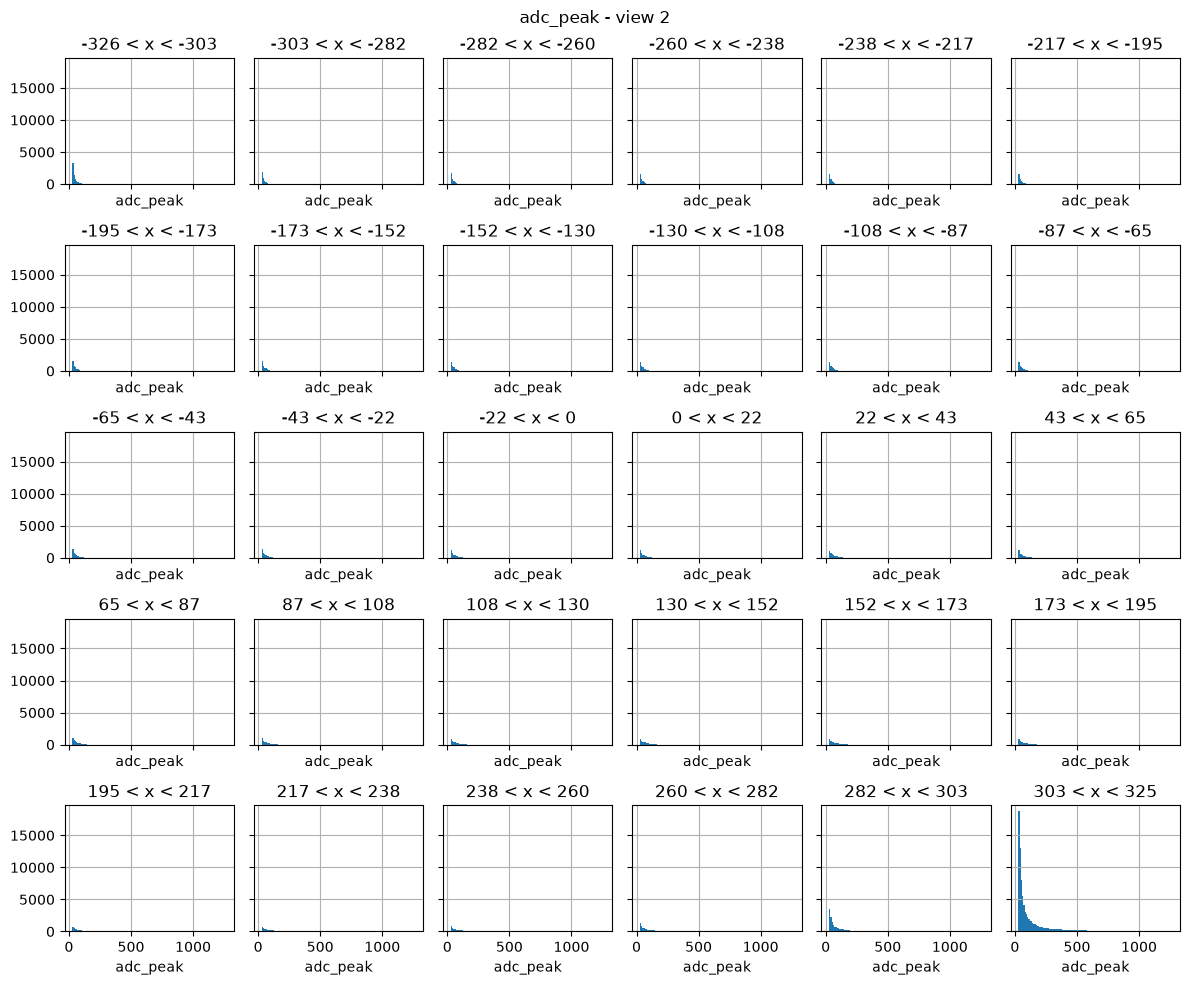

In [35]:
fig = tp_ana.draw_variable_in_drift_grid('adc_peak', bin_size=10, sharex=True, sharey=True, figsize=(12,10))
fig.tight_layout()

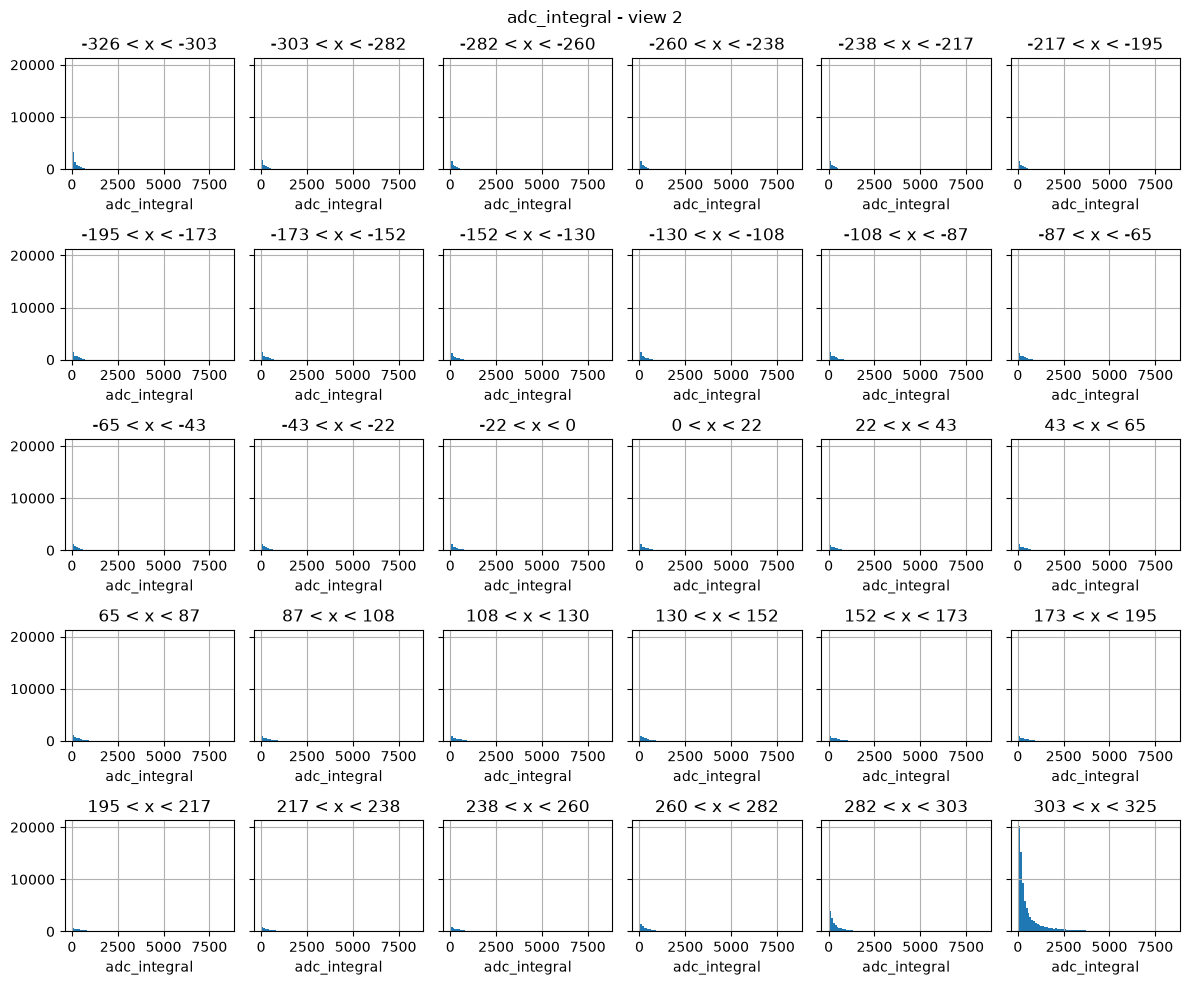

In [36]:
fig = tp_ana.draw_variable_in_drift_grid('adc_integral', bin_size=100, sharey=True, figsize=(12,10))
fig.tight_layout()

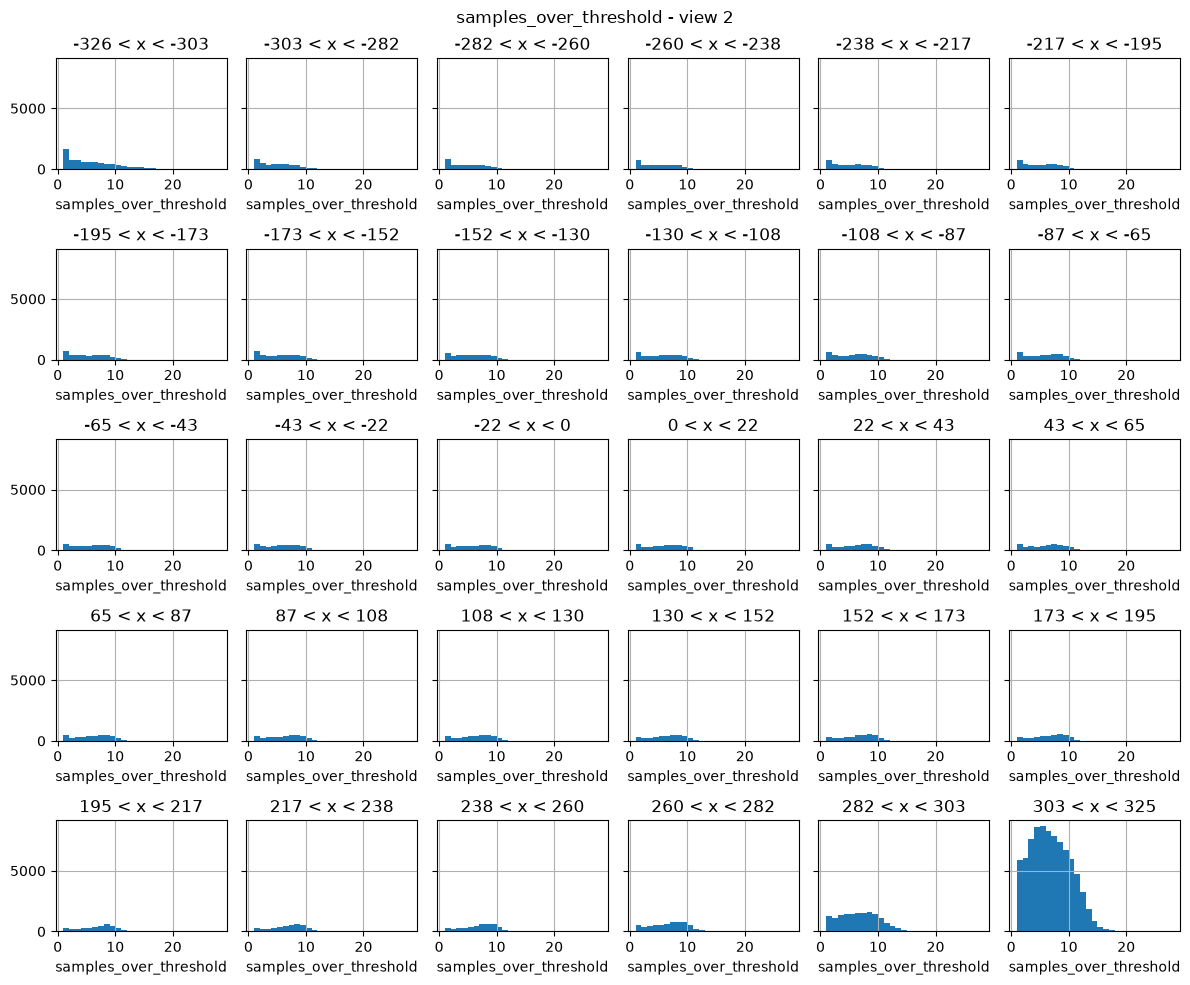

In [37]:
fig = tp_ana.draw_variable_in_drift_grid('samples_over_threshold', bin_size=1, log=False, sharey=True, figsize=(12,10))
fig.tight_layout()

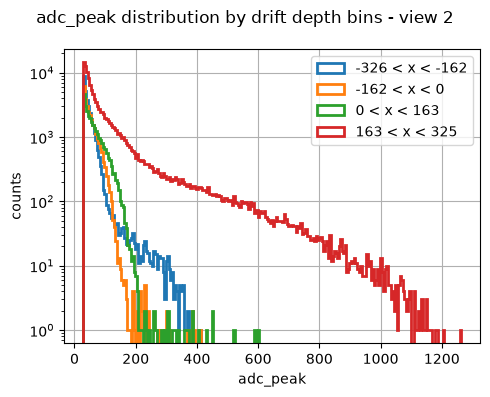

In [38]:
fig = tp_ana.draw_variable_drift_stack('adc_peak', bin_size=5, n_x_bins=4, log=True, figsize=(5,4))
fig.tight_layout()

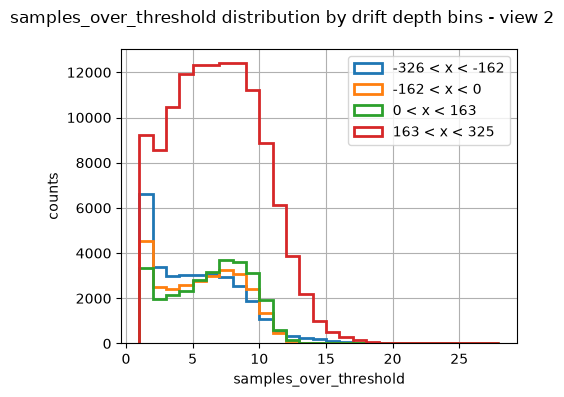

In [39]:
fig = tp_ana.draw_variable_drift_stack('samples_over_threshold', bin_size=1, n_x_bins=4, log=False, figsize=(5,4))
fig.tight_layout()


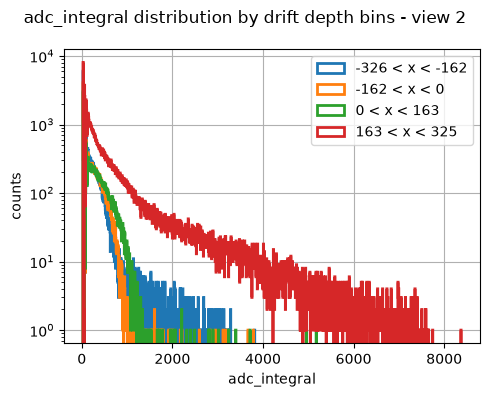

In [40]:
fig = tp_ana.draw_variable_drift_stack('adc_integral', bin_size=5, n_x_bins=4, log=True, figsize=(5,4))
fig.tight_layout()


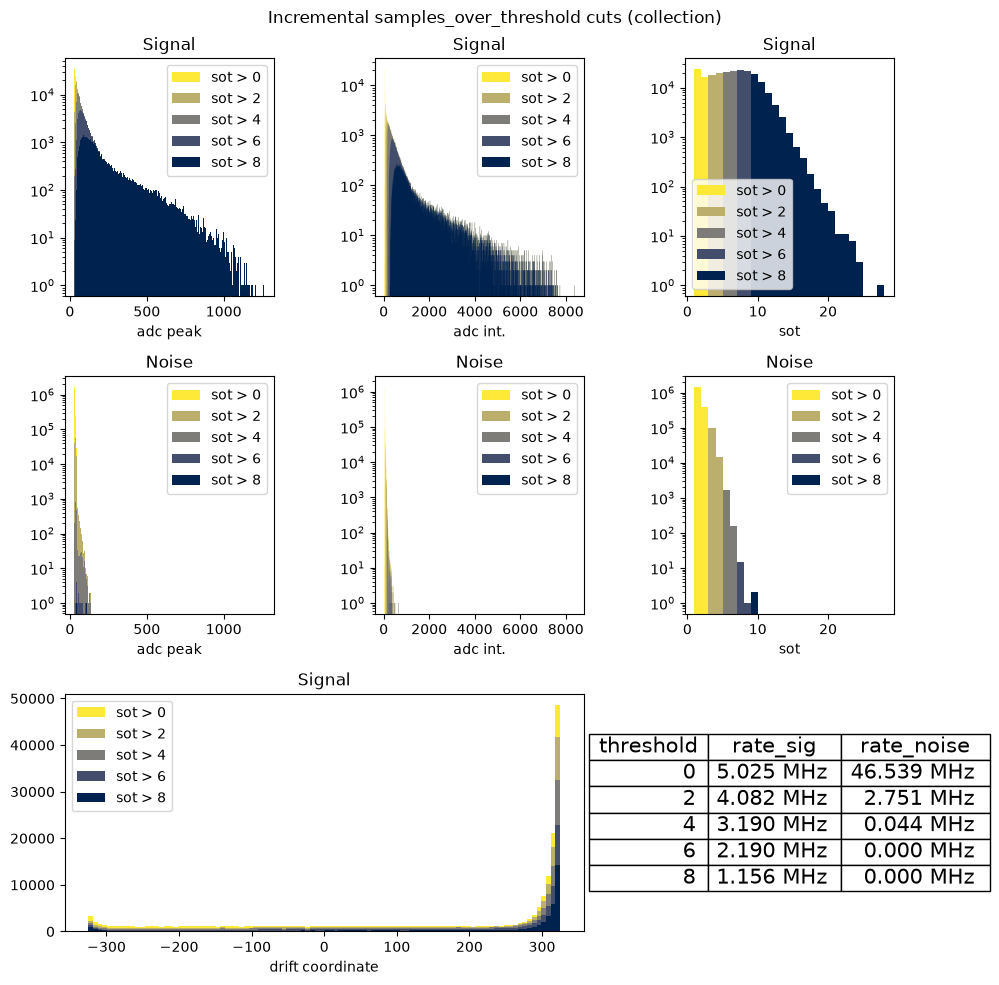

In [41]:
tot_cuts = [t for t in range(0,10,2)]

fig = tp_ana.draw_variable_cut_sequence('samples_over_threshold', tot_cuts, log=True, figsize=(10,10))


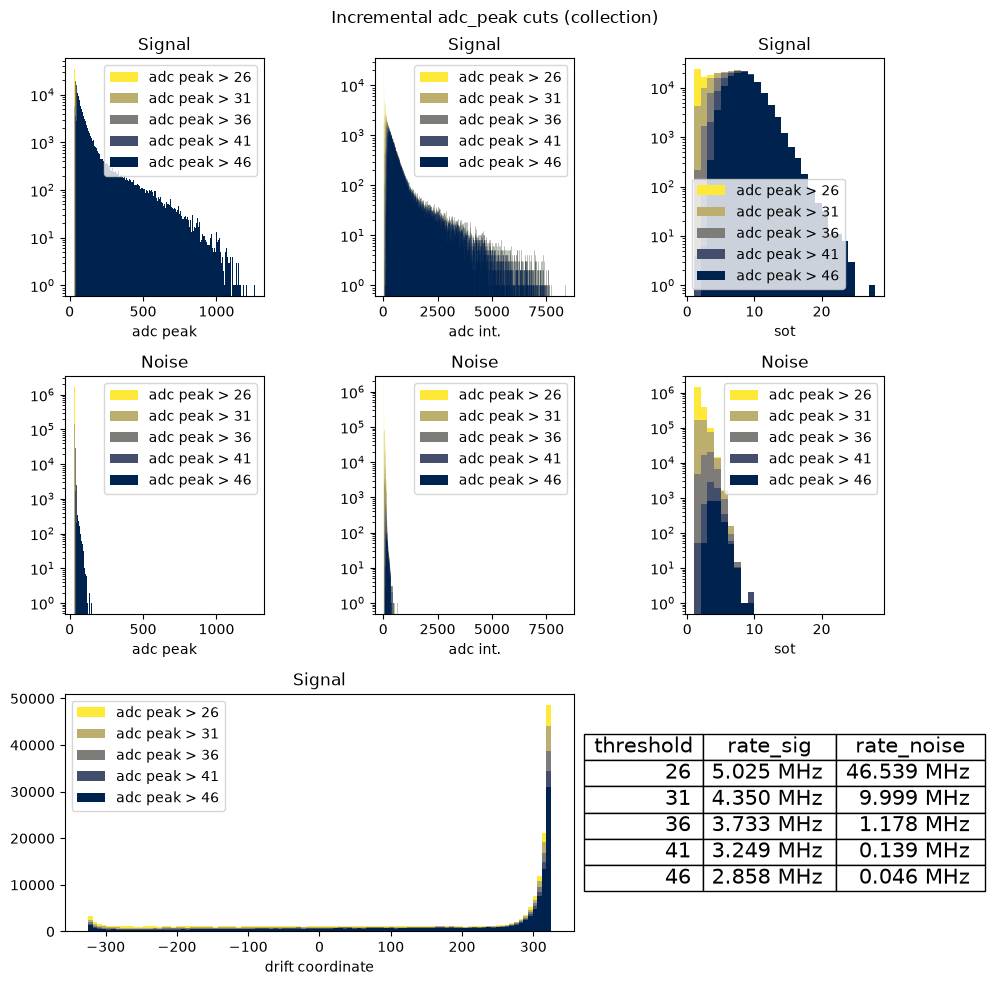

In [42]:
cuts = [t for t in range(26, 50, 5)]

fig = tp_ana.draw_variable_cut_sequence('adc_peak', cuts, log=True, figsize=(10,10))
fig.tight_layout()

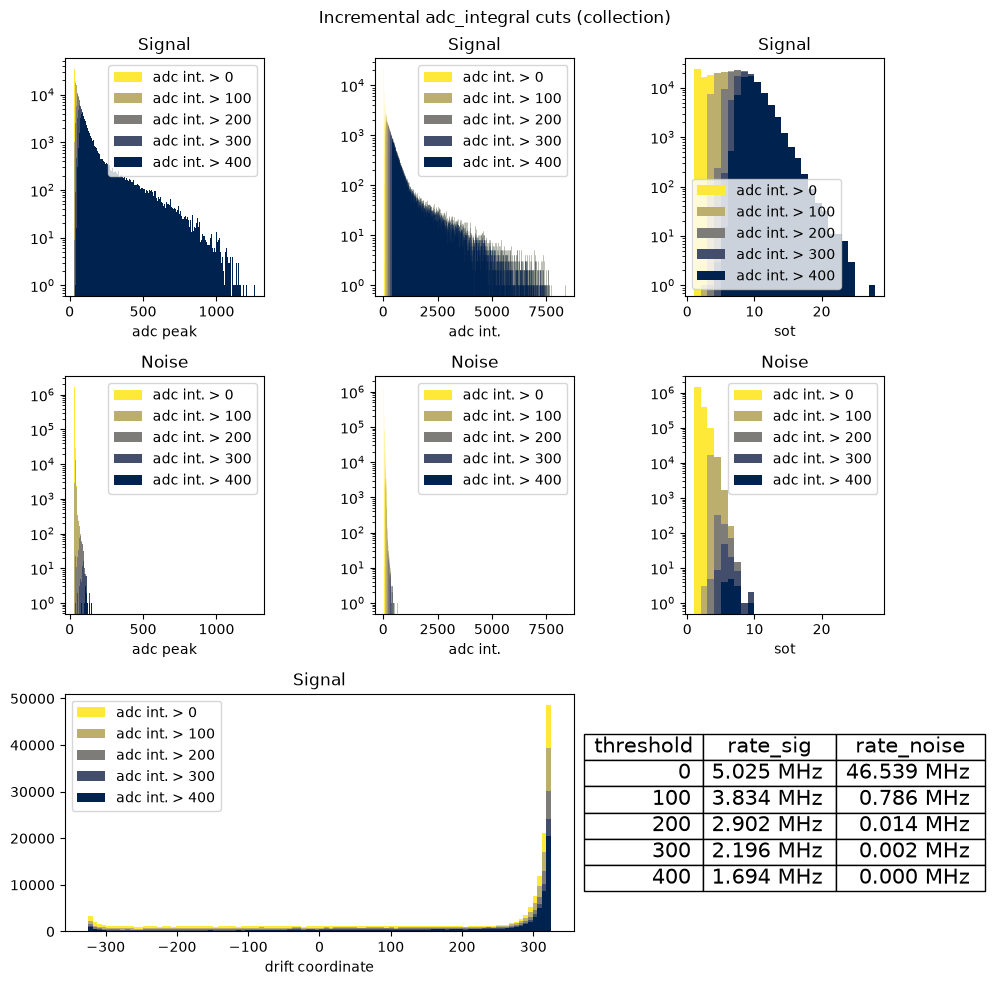

In [43]:
cuts = [t for t in range(0, 500, 100)]

fig = tp_ana.draw_variable_cut_sequence('adc_integral', cuts, figsize=(10,10), log=True)
fig.tight_layout()

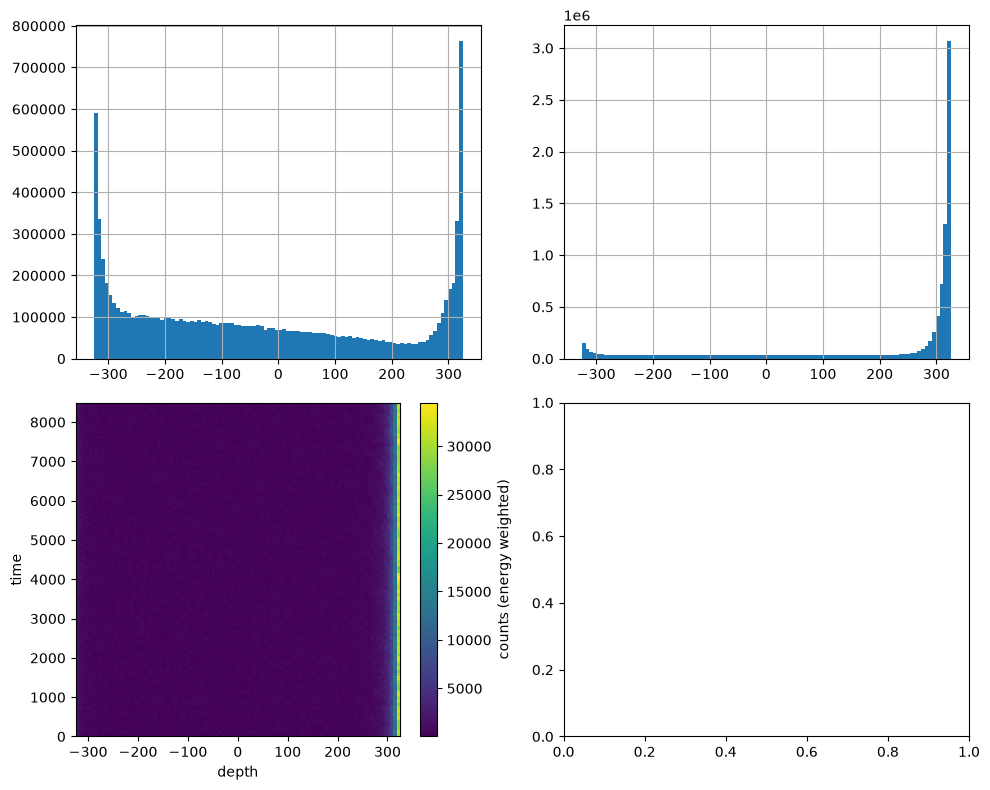

In [50]:
import matplotlib as mpl
fig, axes = plt.subplots(2,2, figsize=(10,8))
norm=mpl.colors.LogNorm()
ides_clean = rad_ws.simides.query('timestamp < 10000')


ax=axes[0][0]
ides_clean.x.hist(bins=100, ax=ax)
ax=axes[0][1]
ides_clean.x.hist(bins=100, weights=ides_clean.energy, ax=ax)
ax = axes[1][0]
h2d = ax.hist2d(ides_clean.x, ides_clean.timestamp, weights=ides_clean.energy, bins=(100, 100))
ax.set_ylabel('time')
ax.set_xlabel('depth')
cbar = fig.colorbar(h2d[3], ax=ax)
cbar.set_label('counts (energy weighted)')
fig.tight_layout()


Ar39GenInLAr                   103800
CavernwallGammasAtLAr1x8x14     96025
Kr85GenInLAr                    13137
foamGammasAtLAr1x8x14            3888
Th232ChainGenInCathode           3623
Th232ChainGenInAnode             2489
U238ChainGenInCathode            1032
U238ChainGenInAnode              1030
Name: count, dtype: int64

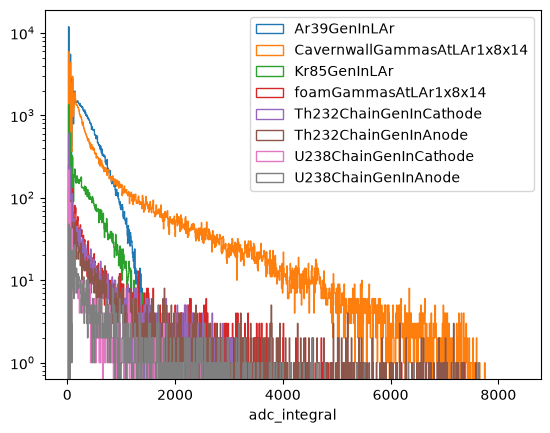

Rate per CRP
Ar39GenInLAr                   21625.000000
CavernwallGammasAtLAr1x8x14    20005.208333
Kr85GenInLAr                    2736.875000
foamGammasAtLAr1x8x14            810.000000
Th232ChainGenInCathode           754.791667
Th232ChainGenInAnode             518.541667
U238ChainGenInCathode            215.000000
U238ChainGenInAnode              214.583333
Name: count, dtype: float64 Hz

In [51]:
tp_bgd = rad_ws.tps[rad_ws.tps.samples_over_threshold >0]
# tp_bgd = ws.tps
# Count entries per generator and get top N culprits
N = 8
# tps_filtered = tp_bgd[(tp_bgd.readout_plane_id == 2)] # & (tp_bgd.samples_over_threshold > 0)]
tps_filtered = tp_bgd.query('bt_is_signal==1 & readout_plane_id == 2') # & (tp_bgd.samples_over_threshold > 0)]
generator_names_np = tps_filtered.bt_generator_name.to_numpy()
top_n = pd.Series(generator_names_np).value_counts().nlargest(N)
print(top_n)
top = pd.Series(generator_names_np).value_counts().nlargest(N).index
plt.yscale('log')
plt.xlabel('adc_integral')

bin_max = max([tps_filtered.loc[tps_filtered.bt_generator_name == top[i]]['adc_integral'].max() for i in range(0,len(top))])
bins=list(range(0, int(bin_max), 8))

for i in range(0,len(top)):
    plt.hist(tps_filtered.loc[tps_filtered.bt_generator_name == top[i], 'adc_integral'], bins=bins, histtype='step', label=f'{top[i]}')
plt.legend()
plt.show()
print(f"Rate per CRP\n{top_n/(100*8000*0.5e-6)/12} Hz")


Ar39GenInLAr                   103800
CavernwallGammasAtLAr1x8x14     96025
Kr85GenInLAr                    13137
foamGammasAtLAr1x8x14            3888
Th232ChainGenInCathode           3623
Th232ChainGenInAnode             2489
U238ChainGenInCathode            1032
U238ChainGenInAnode              1030
Name: count, dtype: int64

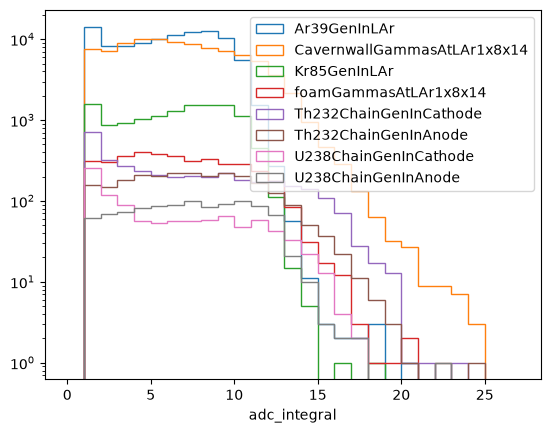

Rate per CRP
Ar39GenInLAr                   21625.000000
CavernwallGammasAtLAr1x8x14    20005.208333
Kr85GenInLAr                    2736.875000
foamGammasAtLAr1x8x14            810.000000
Th232ChainGenInCathode           754.791667
Th232ChainGenInAnode             518.541667
U238ChainGenInCathode            215.000000
U238ChainGenInAnode              214.583333
Name: count, dtype: float64 Hz

In [52]:
tp_bgd = rad_ws.tps[rad_ws.tps.samples_over_threshold >0]
# tp_bgd = ws.tps
# Count entries per generator and get top N culprits
N = 8
# tps_filtered = tp_bgd[(tp_bgd.readout_plane_id == 2)] # & (tp_bgd.samples_over_threshold > 0)]
tps_filtered = tp_bgd.query('bt_is_signal==1 & readout_plane_id == 2') # & (tp_bgd.samples_over_threshold > 0)]
generator_names_np = tps_filtered.bt_generator_name.to_numpy()
top_n = pd.Series(generator_names_np).value_counts().nlargest(N)
print(top_n)
top = pd.Series(generator_names_np).value_counts().nlargest(N).index
plt.yscale('log')
plt.xlabel('adc_integral')

bin_max = max([tps_filtered.loc[tps_filtered.bt_generator_name == top[i]]['samples_over_threshold'].max() for i in range(0,len(top))])
bins=list(range(bin_max))

for i in range(0,len(top)):
    plt.hist(tps_filtered.loc[tps_filtered.bt_generator_name == top[i], 'samples_over_threshold'], bins=bins, histtype='step', label=f'{top[i]}')
plt.legend()
plt.show()
print(f"Rate per CRP\n{top_n/(100*8000*0.5e-6)/12} Hz")


In [55]:
len(rad_ws.tps.query('bt_is_signal == 1 & readout_plane_id == 2'))/(100*8000*0.5e-6)/12*160/1e6

7.556633333333334

In [56]:
from dunetrg.analysis.utils import calculate_trg_obj_rates
from rich.table import Table


for i, df in tps_filtered.groupby('bt_generator_name'):
    print(i, calculate_trg_obj_rates(df, 8000))
    # break


pd.DataFrame([[g, calculate_trg_obj_rates(df, 8000)] for g, df in tps_filtered.groupby('bt_generator_name')])


Ar39GenInLAr 2595000.0

Ar42GenInLAr 375.0

CavernwallGammasAtLAr1x8x14 2400625.0

K40GenInAnode 3250.0

K40GenInCathode 3775.0

...

Th232ChainGenInCathode 90575.0

U238ChainGenInAnode 25750.0

U238ChainGenInCathode 25800.0

foamGammasAtLAr1x8x14 97200.0

,0,1
0,Ar39GenInLAr,2595000.0
1,Ar42GenInLAr,375.0
2,CavernwallGammasAtLAr1x8x14,2400625.0
3,K40GenInAnode,3250.0
4,K40GenInCathode,3775.0
5,K42From42ArGenInLAr,75.0
6,K42From42ArGenInUpperMesh1x8x14,925.0
7,Kr85GenInLAr,328425.0
8,Rn220ChainFromPb212GenInUpperMesh1x8x14,5450.0
9,Rn220ChainPb212GenInLAr,3100.0


In [58]:
n_crp_fd = 160
n_crp_sim = 12
n_ev = len(rad_ws.event_summary)
drift_time = 8000*16e-9*31.25

x = n_crp_fd/(n_crp_sim*drift_time*n_ev)


print(x, drift_time)

for i in range(0,len(top)):

    print(top[i], top_n.iloc[i], top_n.iloc[i]*x/1e6 )

333.33333333333326 0.004000000000000001

Ar39GenInLAr 103800 34.599999999999994

CavernwallGammasAtLAr1x8x14 96025 32.008333333333326

Kr85GenInLAr 13137 4.378999999999999

foamGammasAtLAr1x8x14 3888 1.2959999999999998

Th232ChainGenInCathode 3623 1.2076666666666662

Th232ChainGenInAnode 2489 0.8296666666666666

U238ChainGenInCathode 1032 0.3439999999999999

U238ChainGenInAnode 1030 0.34333333333333327

In [59]:
tpw.all.groupby('event').sample_start.max()-tpw.all.groupby('event').sample_start.min()

event
1    7998
2    7998
3    7998
4    7998
5    7998
Name: sample_start, dtype: uint64

<Axes: >

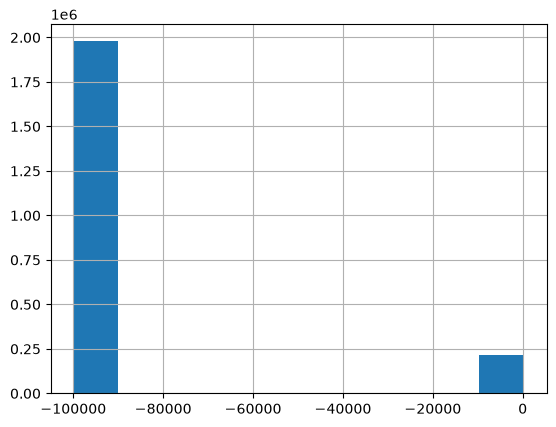

In [60]:
tpw.p2.bt_x.hist()

In [61]:
from dunetrg.analysis.viz.backtracker import BackTrackerPlotter

In [64]:
bt = BackTrackerPlotter(rad_ws)

In [65]:
tps_ev1 = tpw.query('event==1')
display(tps_ev1.p2)

event    run  subrun  version  flag  detid  channel  \
entry subentry                                                        
0     3826          1  99001       0        2     0      3    96476   
      3827          1  99001       0        2     0      3    96476   
      3828          1  99001       0        2     0      3    96476   
      3829          1  99001       0        2     0      3    96476   
      3830          1  99001       0        2     0      3    96476   
...               ...    ...     ...      ...   ...    ...      ...   
5     668529        1  99001       1        2     0      3      862   
      668530        1  99001       1        2     0      3      862   
      668532        1  99001       1        2     0      3      863   
      668533        1  99001       1        2     0      3      863   
      668534        1  99001       1        2     0      3      863   

                samples_over_threshold  time_start  samples_to_peak  ...  \
entry subentry                                                       ...   
0     3826                           2       35264                0  ...   
      3827                           1       93728                0  ...   
      3828                           1      142016                0  ...   
      3829                           1      153664                0  ...   
      3830                           2      163936                1  ...   
...                                ...         ...              ...  ...   
5     668529                         1      158432                0  ...   
      668530                         1      239872                0  ...   
      668532                         2       68352                1  ...   
      668533                         1      171520                0  ...   
      668534                         1      217952                0  ...   

                bt_primary_x  bt_primary_y  bt_primary_z  bt_truth_block_id  \
entry subentry                                                                
0     3826     -99999.000000 -99999.000000 -99999.000000             -99999   
      3827     -99999.000000 -99999.000000 -99999.000000             -99999   
      3828     -99999.000000 -99999.000000 -99999.000000             -99999   
      3829     -99999.000000 -99999.000000 -99999.000000             -99999   
      3830     -99999.000000 -99999.000000 -99999.000000             -99999   
...                      ...           ...           ...                ...   
5     668529   -99999.000000 -99999.000000 -99999.000000             -99999   
      668530   -99999.000000 -99999.000000 -99999.000000             -99999   
      668532      323.478699   -640.593628    149.625473                 10   
      668533   -99999.000000 -99999.000000 -99999.000000             -99999   
      668534   -99999.000000 -99999.000000 -99999.000000             -99999   

                          bt_generator_name    event_uid  time_peak  \
entry subentry                                                        
0     3826                                   99001000001      35264   
      3827                                   99001000001      93728   
      3828                                   99001000001     142016   
      3829                                   99001000001     153664   
      3830                                   99001000001     163968   
...                                     ...          ...        ...   
5     668529                                 99001000101     158432   
      668530                                 99001000101     239872   
      668532    CavernwallGammasAtLAr1x8x14  99001000101      68384   
      668533                                 99001000101     171520   
      668534                                 99001000101     217952   

                sample_start  sample_peak  bt_is_signal  
entry subentry                                           
0     3826              1102       

In [66]:
tps_ev1.p2.query("adc_integral < 1000").iloc[:9]

event    run  subrun  version  flag  detid  channel  \
entry subentry                                                        
0     3826          1  99001       0        2     0      3    96476   
      3827          1  99001       0        2     0      3    96476   
      3828          1  99001       0        2     0      3    96476   
      3829          1  99001       0        2     0      3    96476   
      3830          1  99001       0        2     0      3    96476   
      3831          1  99001       0        2     0      3    96476   
      3832          1  99001       0        2     0      3    96476   
      3833          1  99001       0        2     0      3    96476   
      3834          1  99001       0        2     0      3    96476   

                samples_over_threshold  time_start  samples_to_peak  ...  \
entry subentry                                                       ...   
0     3826                           2       35264                0  ...   
      3827                           1       93728                0  ...   
      3828                           1      142016                0  ...   
      3829                           1      153664                0  ...   
      3830                           2      163936                1  ...   
      3831                           1      207584                0  ...   
      3832                           1      207648                0  ...   
      3833                           1      225440                0  ...   
      3834                           1      226144                0  ...   

                bt_primary_x  bt_primary_y  bt_primary_z  bt_truth_block_id  \
entry subentry                                                                
0     3826          -99999.0      -99999.0      -99999.0             -99999   
      3827          -99999.0      -99999.0      -99999.0             -99999   
      3828          -99999.0      -99999.0      -99999.0             -99999   
      3829          -99999.0      -99999.0      -99999.0             -99999   
      3830          -99999.0      -99999.0      -99999.0             -99999   
      3831          -99999.0      -99999.0      -99999.0             -99999   
      3832          -99999.0      -99999.0      -99999.0             -99999   
      3833          -99999.0      -99999.0      -99999.0             -99999   
      3834          -99999.0      -99999.0      -99999.0             -99999   

                bt_generator_name    event_uid  time_peak  sample_start  \
entry subentry                                                            
0     3826                         99001000001      35264          1102   
      3827                         99001000001      93728          2929   
      3828                         99001000001     142016          4438   
      3829                         99001000001     153664          4802   
      3830                         99001000001     163968          5123   
      3831                         99001000001     207584          6487   
      3832                         99001000001     207648          6489   
      3833                         99001000001     225440          7045   
      3834                         99001000001     226144          7067   

                sample_peak  bt_is_signal  
entry subentry                             
0     3826             1102             0  
      3827             2929             0  
      3828             4438             0  
      3829             4802             0  
      3830             5124             0  
      3831             6487             0  
      3832             6489             0  
      3833             7045             0  
      3834             7067             0  

[9 rows x 33 columns]